# HVSR paso a paso: del registro a la interpretacion geologica

**Guia reproducible y cuaderno de estudio** para reconstruir el flujo de referencia MATLAB: control de senales, seleccion STA/LTA, espectros, suavizado Konno-Ohmachi, cociente H/V, pico $f_0$, dispersion y criterios tipo SESAME.

> **Lectura responsable:** este cuaderno separa la reproduccion literal de ciertas decisiones MATLAB de una opcion de procesamiento recomendada. Los resultados dependen del orden correcto de canales, la calidad del registro, la respuesta instrumental y los supuestos geologicos.

## Recorrido

1. Configurar parametros y localizar archivos.
2. Validar metadatos, canales y sincronizacion.
3. Explorar las trazas y aplicar preprocesamiento.
4. Seleccionar ventanas estables con STA/LTA.
5. Calcular FFT, suavizar espectros y formar H/V.
6. Resumir picos, dispersion y criterios de calidad.
7. Probar estabilidad, sensibilidad y significado geologico.
8. Exportar resultados y metadatos del experimento.

```text
SAC (E, N, Z) -> validacion -> quitar media/taper -> STA/LTA -> ventanas
      -> FFT por componente -> suavizado KO -> H/V por ventana
      -> media geometrica +/- dispersion -> f0, A0 -> controles -> interpretacion
```

In [3]:
from pathlib import Path
import importlib.util
import logging
import platform
import numpy as np
import matplotlib.pyplot as plt

SEED = 20261002
rng = np.random.default_rng(SEED)
logging.basicConfig(level=logging.INFO, format="%(levelname)s: %(message)s")
logger = logging.getLogger("hvsr-study")

PARAMS = {
    "lta_s": 25.0, "sta_s": 2.0,
    "ratio_min": 0.2, "ratio_max": 2.0,
    "window_min_s": 32.0, "window_max_s": 40.0,
    "variable_windows": False, "overlap_percent": 0.0,
    "smoothing": "konno-ohmachi", "ko_b": 40.0,
    "trigger_mode": 1, "sensor_low_hz": 0.5,
    "decimation": 1, "fmax_hz": 30.0,
}

# Find the project root without assuming the notebook's current working directory.
_search_starts = [Path.cwd().resolve(), Path(__file__).resolve().parent if "__file__" in globals() else Path.cwd().resolve()]
PROJECT_ROOT = next(
    (parent for start in _search_starts for parent in (start, *start.parents)
     if (parent / "HVMATLAB").is_dir()),
    Path.cwd().resolve(),
)
SAC_DIR = PROJECT_ROOT / "HVMATLAB"
HAS_OBSPY = importlib.util.find_spec("obspy") is not None

print(f"Python: {platform.python_version()} | NumPy: {np.__version__} | Matplotlib: {plt.matplotlib.__version__}")
print(f"Raíz detectada: {PROJECT_ROOT}")
print(f"ObsPy disponible: {HAS_OBSPY}")
print(f"Parámetros base: {PARAMS}")

Python: 3.11.16 | NumPy: 2.4.6 | Matplotlib: 3.11.2
Raíz detectada: /home/orincon/ciudad-perdida-hvsr
ObsPy disponible: True
Parámetros base: {'lta_s': 25.0, 'sta_s': 2.0, 'ratio_min': 0.2, 'ratio_max': 2.0, 'window_min_s': 32.0, 'window_max_s': 40.0, 'variable_windows': False, 'overlap_percent': 0.0, 'smoothing': 'konno-ohmachi', 'ko_b': 40.0, 'trigger_mode': 1, 'sensor_low_hz': 0.5, 'decimation': 1, 'fmax_hz': 30.0}


## 1. Configuracion y parametros del experimento

La primera celda fija una semilla, crea un generador aleatorio y busca la raiz del proyecto desde el directorio de trabajo o la ruta del notebook. `PARAMS` recoge los valores de `HVMATLAB/input.txt`; cada funcion recibe o consulta estos mismos nombres para evitar parametros escondidos.

| Variable | Valor base | Papel en el analisis |
|---|---:|---|
| `lta_s`, `sta_s` | 25 s, 2 s | Duraciones de promedios largo y corto. Debe cumplirse `sta_s < lta_s`. |
| `ratio_min`, `ratio_max` | 0.2, 2 | Banda admitida para STA/LTA; el codigo conserva puntos dentro de ambos limites. |
| `window_min_s`, `window_max_s` | 32 s, 40 s | Duracion minima y maxima si se habilita seleccion variable. |
| `variable_windows` | `False` | Equivale al modo MATLAB `tvar=0`: ventanas fijas de 32 s. |
| `overlap_percent` | 0 % | Fraccion compartida entre ventanas consecutivas. |
| `smoothing`, `ko_b` | KO, 40 | Tipo y ancho del suavizado espectral Konno-Ohmachi. |
| `trigger_mode` | 1 | 1 usa magnitud vectorial; 0 evalua cada componente. |
| `sensor_low_hz`, `fmax_hz` | 0.5, 30 Hz | Banda de busqueda/analisis, limitada por Nyquist. |
| `decimation` | 1 | No decimar. Se conserva solo como registro: el flujo SAC de referencia no lo aplica. |

Para instalar el entorno del repositorio, anade ObsPy al entorno Conda existente (se documenta al final); NumPy y Matplotlib ya son dependencias transitivas de Matplotlib.

## 2. Carga y validacion de datos

El nombre FDSN/SAC `HHE`, `HHN`, `HHZ` distingue este, norte y vertical; las letras iniciales describen banda e instrumento, no las unidades almacenadas. SAC suele guardar cuentas digitales. Para convertirlas a m/s o m/s² hacen falta metadatos de respuesta/calibracion. En el cociente H/V las unidades se cancelan solo si las tres respuestas instrumentales son compatibles.

La matriz se ordena deliberadamente como `[Z, N, E]`, porque la rutina de referencia divide por la primera componente y combina las dos siguientes. La celda valida numero de muestras, `delta`, frecuencia de muestreo y tiempo de inicio. Si se usa una simulacion, debe cambiarse `DATA_SOURCE` explicitamente; nunca se sustituye silenciosamente un archivo faltante.

In [20]:
DATA_SOURCE = "SAC"  # Cambiar manualmente a "synthetic" solo para demostraciones.
SAC_FILES = {
    "E": SAC_DIR / "00P2-2_WA.WAU40..HHE.D.2020.281.sac",
    "N": SAC_DIR / "00P2-2_WA.WAU40..HHN.D.2020.281.sac",
    "Z": SAC_DIR / "00P2-2_WA.WAU40..HHZ.D.2020.281.sac",
}


def make_synthetic_records(fs=100.0, duration_s=192.0, seed=SEED):
    """Crea un ejemplo didactico con respuesta horizontal mayor cerca de 0.7 Hz."""
    local_rng = np.random.default_rng(seed)
    time_s = np.arange(round(fs * duration_s)) / fs
    z = np.sin(2 * np.pi * 0.7 * time_s) + 0.25 * np.sin(2 * np.pi * 3.0 * time_s)
    n = 3.0 * np.sin(2 * np.pi * 0.7 * time_s + 0.2) + 0.3 * np.sin(2 * np.pi * 3.0 * time_s)
    e = 2.5 * np.sin(2 * np.pi * 0.7 * time_s - 0.3) + 0.35 * np.sin(2 * np.pi * 3.0 * time_s)
    z += 0.04 * local_rng.standard_normal(time_s.size)
    n += 0.04 * local_rng.standard_normal(time_s.size)
    e += 0.04 * local_rng.standard_normal(time_s.size)
    return np.column_stack((z, n, e)), time_s, fs, 1.0 / fs


if DATA_SOURCE == "SAC":
    missing_files = [str(path) for path in SAC_FILES.values() if not path.is_file()]
    if missing_files:
        raise FileNotFoundError("Faltan SAC: " + ", ".join(missing_files) + ". Para estudiar sin ellos, cambia DATA_SOURCE explicitamente a 'synthetic'.")
    if not HAS_OBSPY:
        raise ModuleNotFoundError("Para leer SAC instala ObsPy: conda install -c conda-forge obspy. Alternativamente, cambia DATA_SOURCE a 'synthetic'.")
    read = __import__("obspy").read

    traces = {component: read(str(path), format="SAC")[0] for component, path in SAC_FILES.items()}
    reference = traces["Z"]
    fs = float(reference.stats.sampling_rate)
    dt = float(reference.stats.delta)
    for component, trace in traces.items():
        assert trace.stats.npts == reference.stats.npts, f"Longitud distinta en canal {component}"
        assert np.isclose(trace.stats.delta, dt), f"dt distinto en canal {component}"
        assert trace.stats.starttime == reference.stats.starttime, f"Inicio temporal distinto en canal {component}"
    data = np.column_stack((traces["Z"].data, traces["N"].data, traces["E"].data)).astype(float)
    data_times = np.arange(data.shape[0]) * dt
elif DATA_SOURCE == "synthetic":
    data, data_times, fs, dt = make_synthetic_records()
else:
    raise ValueError("DATA_SOURCE debe ser 'SAC' o 'synthetic'.")

nyquist = fs / 2.0
assert data.ndim == 2 and data.shape[1] == 3
assert data.shape[0] == data_times.size
assert np.all(np.isfinite(data)), "Hay NaN/inf en las trazas"
assert PARAMS["fmax_hz"] <= nyquist, f"fmax={PARAMS['fmax_hz']} Hz supera Nyquist={nyquist} Hz"

print(f"Fuente: {DATA_SOURCE}; Data.shape={data.shape}; duracion={(len(data)-1)*dt:.3f} s")
print(f"dt={dt:.8g} s; Fs={fs:.6g} Hz; Nyquist={nyquist:.6g} Hz")
print(f"Canales en columnas: Z, N, E; fmax={PARAMS['fmax_hz']} Hz")
if DATA_SOURCE == "SAC":
    for component, trace in traces.items():
        print(component, trace.id, "npts=", trace.stats.npts, "start=", trace.stats.starttime)

Fuente: SAC; Data.shape=(2816100, 3); duracion=28160.990 s
dt=0.01 s; Fs=100 Hz; Nyquist=50 Hz
Canales en columnas: Z, N, E; fmax=30.0 Hz
E .00P2-2..E npts= 2816100 start= 2020-10-07T08:18:39.000000Z
N .00P2-2..N npts= 2816100 start= 2020-10-07T08:18:39.000000Z
Z .00P2-2..Z npts= 2816100 start= 2020-10-07T08:18:39.000000Z


## 3. Exploracion temporal y preprocesamiento

Para cada componente se elimina el offset:

$$x_c[n]=x[n]-\bar{x},\qquad \bar{x}=\frac{1}{N}\sum_{n=0}^{N-1}x[n].$$

Luego se reduce el peso de los bordes para disminuir discontinuidades antes de la FFT. El MATLAB construye una Hann simetrica completa, $w[n]=\tfrac12(1-\cos(2\pi n/(N-1)))$, pero multiplica solo el primer 2 % por los primeros pesos y el ultimo 2 % por los ultimos pesos. Eso produce un salto entre un peso muy pequeno y peso 1. La grafica siguiente compara esa reproduccion literal con un taper cosenoidal de borde, cuya rampa llega gradualmente a 1.

`TAPER_MODE="cosine"` es la opcion recomendada para el analisis; usa `"matlab-edge"` para imitar el codigo de referencia, incluidos sus bordes. Esa eleccion cambia el resultado y debe registrarse.

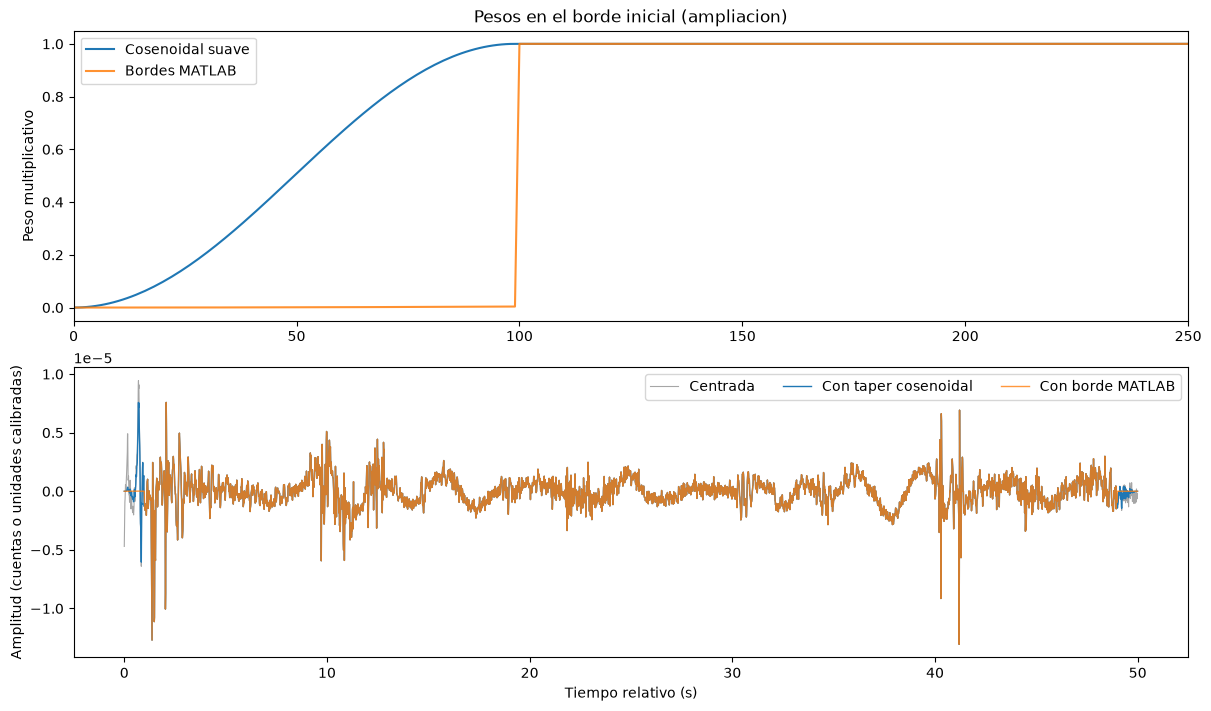

In [5]:
def taper_weights(n, fraction=0.02, mode="cosine"):
    """Pesos de borde: taper cosenoidal suave o reproduccion literal del MATLAB."""
    weights = np.ones(n, dtype=float)
    m = int(np.floor(fraction * n))
    if m == 0:
        return weights
    if mode == "cosine":
        ramp = 0.5 * (1.0 - np.cos(np.pi * np.arange(m) / max(m - 1, 1)))
        weights[:m] = ramp
        weights[-m:] = ramp[::-1]
    elif mode == "matlab-edge":
        full_hann = np.hanning(n)
        weights[:m] = full_hann[:m]
        # MATLAB indices length:-1:length-nw contain nw+1 samples.
        weights[-(m + 1):] = full_hann[-(m + 1):]
    elif mode == "none":
        pass
    else:
        raise ValueError("mode debe ser 'cosine', 'matlab-edge' o 'none'.")
    return weights


def preprocess_trace(signal, mode="cosine", fraction=0.02):
    """Quita la media y aplica los pesos seleccionados, sin modificar el original."""
    centered = np.asarray(signal, dtype=float) - np.mean(signal)
    weights = taper_weights(centered.size, fraction=fraction, mode=mode)
    return centered * weights, weights


TAPER_MODE = "cosine"  # Cambiar a "matlab-edge" para comparacion literal.
_demo_n = min(data.shape[0], 5000)
_demo_signal = data[:_demo_n, 0]
_demo_centered = _demo_signal - np.mean(_demo_signal)
_w_cos = taper_weights(_demo_n, mode="cosine")
_w_mat = taper_weights(_demo_n, mode="matlab-edge")

fig, ax = plt.subplots(2, 1, figsize=(12, 7), constrained_layout=True)
ax[0].plot(np.arange(_demo_n), _w_cos, label="Cosenoidal suave")
ax[0].plot(np.arange(_demo_n), _w_mat, label="Bordes MATLAB", alpha=0.85)
ax[0].set_xlim(0, min(_demo_n - 1, int(0.05 * _demo_n)))
ax[0].set_ylabel("Peso multiplicativo")
ax[0].set_title("Pesos en el borde inicial (ampliacion)")
ax[0].legend()
ax[1].plot(data_times[:_demo_n], _demo_centered, color="0.65", lw=0.8, label="Centrada")
ax[1].plot(data_times[:_demo_n], _demo_centered * _w_cos, lw=1.0, label="Con taper cosenoidal")
ax[1].plot(data_times[:_demo_n], _demo_centered * _w_mat, lw=1.0, label="Con borde MATLAB", alpha=0.8)
ax[1].set_xlabel("Tiempo relativo (s)")
ax[1].set_ylabel("Amplitud (cuentas o unidades calibradas)")
ax[1].legend(ncols=3)
plt.show()

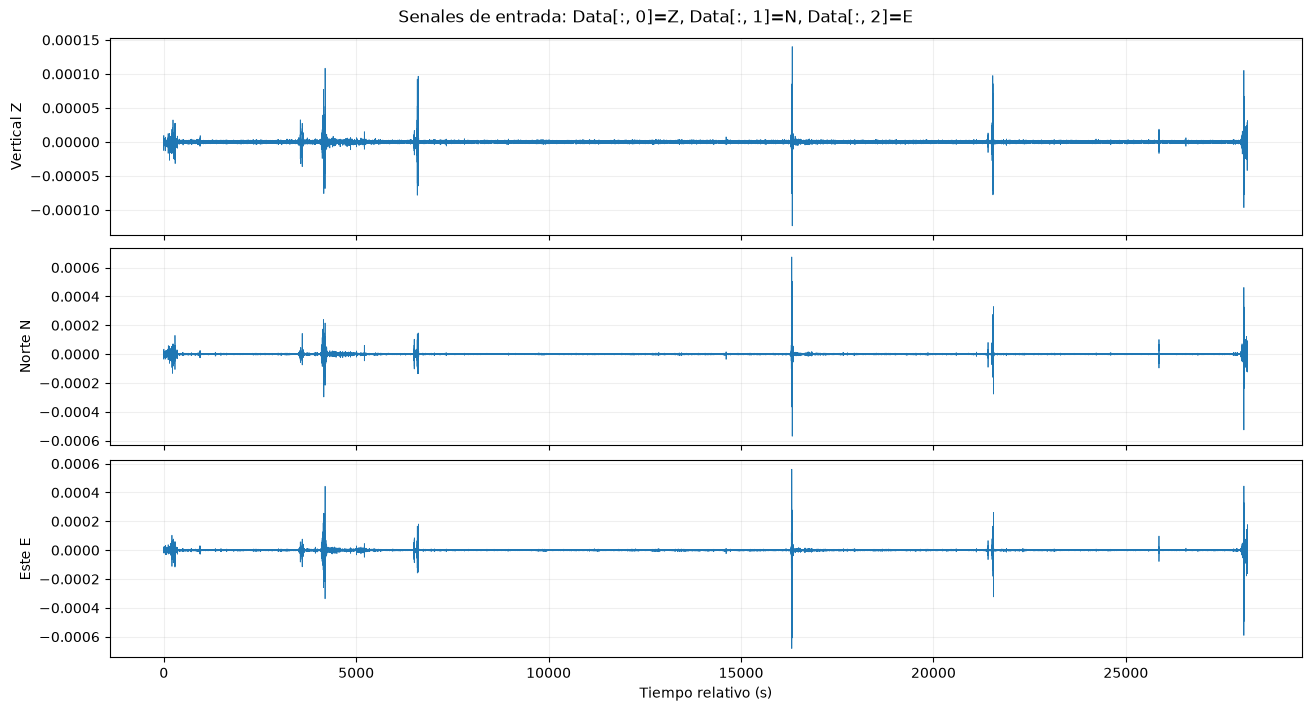

Media por canal antes de centrar: [-1.06268659e-10 -1.76057153e-11  4.28982855e-11]
Desviacion estandar por canal: [1.19532105e-06 3.37262490e-06 3.31019968e-06]


In [6]:
fig, axes = plt.subplots(3, 1, figsize=(13, 7), sharex=True, constrained_layout=True)
for column, label, axis in zip(range(3), ("Vertical Z", "Norte N", "Este E"), axes):
    axis.plot(data_times, data[:, column], lw=0.55)
    axis.set_ylabel(label)
    axis.grid(alpha=0.2)
axes[-1].set_xlabel("Tiempo relativo (s)")
fig.suptitle("Senales de entrada: Data[:, 0]=Z, Data[:, 1]=N, Data[:, 2]=E")
plt.show()

print("Media por canal antes de centrar:", np.mean(data, axis=0))
print("Desviacion estandar por canal:", np.std(data, axis=0, ddof=1))

## 4. STA/LTA y seleccion de ventanas

Con `trigger_mode=1`, el codigo forma la magnitud vectorial $r[n]=\sqrt{Z[n]^2+N[n]^2+E[n]^2}$. Sobre ella calcula promedios moviles **de amplitud**, no de energia cuadratica:

$$STA[n]=\frac{1}{N_s}\sum_{j=0}^{N_s-1}r[n-j],\qquad LTA[n]=\frac{1}{N_l}\sum_{j=0}^{N_l-1}r[n-j],\qquad R[n]=\frac{STA[n]}{LTA[n]}.$$

Las duraciones se convierten a muestras: $N_s=\operatorname{round}(sta\,F_s)$ y $N_l=\operatorname{round}(lta\,F_s)$. El codigo mantiene muestras si `ratio_min < R < ratio_max` y su amplitud no esta entre el 1 % mas extremo del maximo global.

La rutina MATLAB llama a `calculta` con el mismo indice de inicio LTA para STA y LTA. Como efecto, los valores intermedios de STA pueden quedar en cero antes de iniciar ese calculo. `TRIGGER_INIT_MODE="reference"` replica esa inicializacion; `"standard"` calcula cada promedio desde su primera ventana completa. Las ventanas de este cuaderno son rangos Python `[inicio, fin)`; se descarta el resto que no complete la duracion. En MATLAB los indices incluyen ambos extremos, asi que existe una diferencia potencial de una muestra.

In [7]:
def sliding_mean_reference(values, n_window, baseline, first_full_index=None, initialization="standard"):
    """Media movil trailing vectorizada; permite emular la inicializacion MATLAB."""
    values = np.asarray(values, dtype=float)
    if n_window < 1:
        raise ValueError("n_window debe ser >= 1.")
    if initialization == "standard":
        first_full_index = n_window - 1
    elif initialization == "reference":
        if first_full_index is None:
            raise ValueError("El modo reference necesita first_full_index.")
    else:
        raise ValueError("initialization debe ser 'standard' o 'reference'.")

    out = np.zeros(values.size, dtype=float)
    if initialization == "standard":
        out[:first_full_index] = baseline
    else:
        out[:max(n_window - 1, 0)] = baseline
    if first_full_index >= values.size:
        return out
    if first_full_index < n_window - 1:
        raise ValueError("El primer promedio completo precede al tamano de ventana.")

    cumulative = np.concatenate(([0.0], np.cumsum(values, dtype=float)))
    means = (cumulative[n_window:] - cumulative[:-n_window]) / n_window
    first_mean_index = first_full_index - n_window + 1
    out[first_full_index:] = means[first_mean_index:]
    return out


def calculate_trigger(data, fs, params, taper_mode="cosine", initialization="standard"):
    """Calcula magnitud, STA/LTA y mascara de muestras aceptables."""
    prepared = np.column_stack([
        preprocess_trace(data[:, column], mode=taper_mode)[0]
        for column in range(data.shape[1])
    ])
    vector_magnitude = np.sqrt(np.sum(prepared ** 2, axis=1))
    baseline = float(np.mean(vector_magnitude))
    n_lta = max(1, int(round(params["lta_s"] * fs)))
    n_sta = max(1, int(round(params["sta_s"] * fs)))
    if n_sta >= n_lta:
        raise ValueError("STA debe ser mas corta que LTA.")
    first_full = n_lta - 1 if initialization == "reference" else None

    if params["trigger_mode"] == 1:
        target = vector_magnitude
        max_allowed = 0.99 * float(np.max(target))
        lta = sliding_mean_reference(target, n_lta, baseline, first_full, initialization)
        sta = sliding_mean_reference(target, n_sta, baseline, first_full, initialization)
        ratio = np.divide(sta, lta, out=np.zeros_like(sta), where=lta > 0)
        valid = (ratio > params["ratio_min"]) & (ratio < params["ratio_max"]) & (target < max_allowed)
    elif params["trigger_mode"] == 0:
        component_ratios, component_lta, component_sta, component_ok = [], [], [], []
        for column in range(data.shape[1]):
            target = np.abs(prepared[:, column])
            lta_col = sliding_mean_reference(target, n_lta, baseline, first_full, initialization)
            sta_col = sliding_mean_reference(target, n_sta, baseline, first_full, initialization)
            ratio_col = np.divide(sta_col, lta_col, out=np.zeros_like(sta_col), where=lta_col > 0)
            component_lta.append(lta_col)
            component_sta.append(sta_col)
            component_ratios.append(ratio_col)
            component_ok.append((ratio_col > params["ratio_min"]) & (ratio_col < params["ratio_max"]) & (target < 0.99 * np.max(target)))
        ratio = np.column_stack(component_ratios)
        lta = np.column_stack(component_lta)
        sta = np.column_stack(component_sta)
        valid = np.logical_and.reduce(component_ok)
    else:
        raise ValueError("trigger_mode debe ser 0 o 1.")

    return {"prepared": prepared, "magnitude": vector_magnitude, "sta": sta,
            "lta": lta, "ratio": ratio, "valid": valid,
            "n_sta": n_sta, "n_lta": n_lta}


def select_windows(valid_mask, fs, params):
    """Divide corridas aceptadas en ventanas Python [inicio, fin)."""
    minimum = max(1, int(round(params["window_min_s"] * fs)))
    maximum = max(minimum, int(round(params["window_max_s"] * fs)))
    target = maximum if params["variable_windows"] else minimum
    step = max(1, int(round(target * (1.0 - params["overlap_percent"] / 100.0))))
    padded = np.r_[False, valid_mask, False]
    starts = np.flatnonzero(np.diff(padded.astype(int)) == 1)
    ends = np.flatnonzero(np.diff(padded.astype(int)) == -1)
    selected = []
    for run_start, run_end in zip(starts, ends):
        start = int(run_start)
        while start + minimum <= run_end:
            length = min(target, int(run_end) - start)
            if not params["variable_windows"] and length < target:
                break
            selected.append((start, start + length))
            start += step
    return np.asarray(selected, dtype=int).reshape(-1, 2)


TRIGGER_INIT_MODE = "standard"  # Usar "reference" para comparar la inicializacion MATLAB.
trigger_result = calculate_trigger(data, fs, PARAMS, TAPER_MODE, TRIGGER_INIT_MODE)
windows_idx = select_windows(trigger_result["valid"], fs, PARAMS)
print(f"STA={trigger_result['n_sta']} muestras; LTA={trigger_result['n_lta']} muestras")
print(f"Puntos aceptados: {trigger_result['valid'].sum()} / {len(data)}")
print(f"Ventanas elegidas: {len(windows_idx)}; primeras filas [inicio, fin):\n{windows_idx[:5]}")
assert windows_idx.ndim == 2 and windows_idx.shape[1] == 2
assert np.all(windows_idx[:, 1] - windows_idx[:, 0] >= int(PARAMS["window_min_s"] * fs)) if len(windows_idx) else True

STA=200 muestras; LTA=2500 muestras
Puntos aceptados: 2783882 / 2816100
Ventanas elegidas: 842; primeras filas [inicio, fin):
[[29352 32552]
 [35436 38636]
 [38636 41836]
 [41836 45036]
 [45036 48236]]


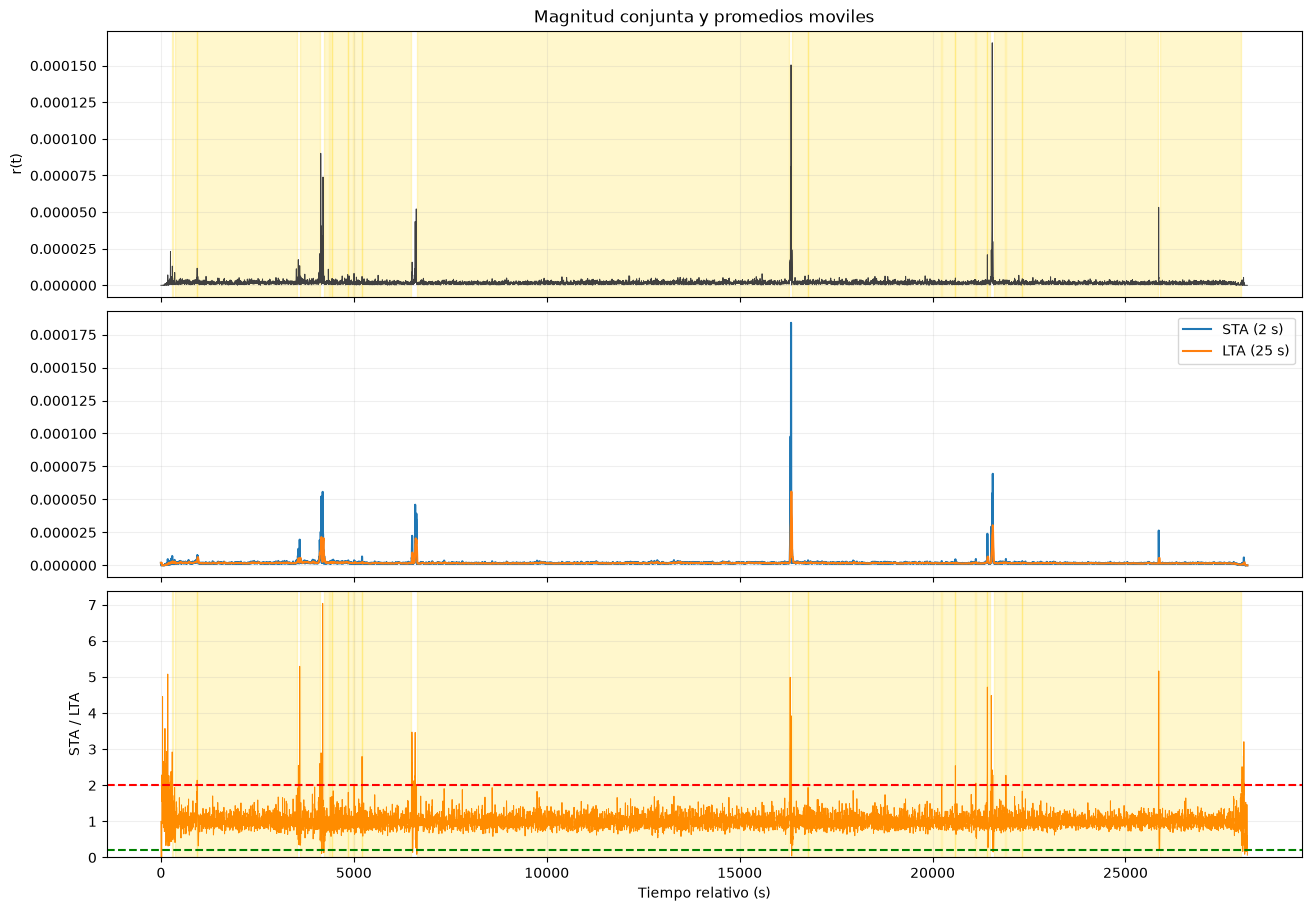

Las 842 ventanas se visualizaron como 21 intervalos contiguos aceptados.


In [9]:
_plot_stride = max(1, len(data_times) // 10000)
fig, axes = plt.subplots(3, 1, figsize=(13, 9), sharex=True, constrained_layout=True)
axes[0].plot(data_times[::_plot_stride], trigger_result["magnitude"][::_plot_stride], color="0.25", lw=0.7)
axes[0].set_ylabel("r(t)")
axes[0].set_title("Magnitud conjunta y promedios moviles")
if trigger_result["sta"].ndim == 1:
    axes[1].plot(data_times[::_plot_stride], trigger_result["sta"][::_plot_stride], label="STA (2 s)")
    axes[1].plot(data_times[::_plot_stride], trigger_result["lta"][::_plot_stride], label="LTA (25 s)")
    axes[1].legend()
    axes[2].plot(data_times[::_plot_stride], trigger_result["ratio"][::_plot_stride], color="darkorange", lw=0.7)
else:
    for channel, label in enumerate(("Z", "N", "E")):
        axes[1].plot(data_times[::_plot_stride], trigger_result["sta"][::_plot_stride, channel], label=f"STA {label}")
        axes[2].plot(data_times[::_plot_stride], trigger_result["ratio"][::_plot_stride, channel], label=f"STA/LTA {label}")
    axes[1].legend(ncols=3)
    axes[2].legend(ncols=3)
axes[2].axhline(PARAMS["ratio_min"], color="green", ls="--", label="Limite inferior")
axes[2].axhline(PARAMS["ratio_max"], color="red", ls="--", label="Limite superior")
axes[2].set_ylim(bottom=0)
axes[2].set_ylabel("STA / LTA")
axes[2].set_xlabel("Tiempo relativo (s)")
merged_windows = []
for start, end in windows_idx:
    if merged_windows and start <= merged_windows[-1][1]:
        merged_windows[-1][1] = int(end)
    else:
        merged_windows.append([int(start), int(end)])
for start, end in merged_windows:
    axes[0].axvspan(data_times[start], data_times[min(end - 1, len(data_times) - 1)], color="gold", alpha=0.20)
    axes[2].axvspan(data_times[start], data_times[min(end - 1, len(data_times) - 1)], color="gold", alpha=0.20)
for axis in axes:
    axis.grid(alpha=0.2)
plt.show()
print(f"Las {len(windows_idx)} ventanas se visualizaron como {len(merged_windows)} intervalos contiguos aceptados.")
if len(windows_idx) == 0:
    print("No se encontraron ventanas: inspecciona el ratio, umbrales, fs y duraciones antes de continuar.")

## 5. Del tramo temporal al espectro

Para cada ventana y componente se resta su media, se aplica el taper elegido y se completa con ceros hasta $L$, la siguiente potencia de dos que cubre la ventana mas larga. La transformada discreta es

$$X[k]=\sum_{n=0}^{L-1}x[n]e^{-j2\pi kn/L},\qquad f_k=\frac{kF_s}{L},\qquad \Delta f=\frac{F_s}{L}.$$

Para una senal real se conservan frecuencias positivas hasta Nyquist $F_s/2$. El padding interpola la malla de frecuencias, pero no agrega informacion ni mejora la resolucion fisica impuesta por la duracion observada. La rutina de referencia usa **magnitud de FFT**, no densidad espectral de potencia; el factor de escala comun se cancela en un cociente si el procesamiento de componentes es coherente.

Se calcula $S(f)=\log_{10}|X(f)|$, se suaviza en esa escala y se vuelve a amplitud lineal. El kernel Konno-Ohmachi es

$$W(f,f_c)=\left[\frac{\sin\{b\log_{10}(f/f_c)\}}{b\log_{10}(f/f_c)}\right]^4,\qquad W(f_c,f_c)=1,$$

$$\widetilde{S}(f_c)=\frac{\sum_f W(f,f_c)S(f)}{\sum_f W(f,f_c)}.$$

Se promedian **amplitudes logaritmicas**, no potencias. El soporte se limita a $f_c/10^{2.5/b}$ y $f_c\,10^{2.5/b}$, como en `liskonno.m`. Un $b$ menor ensancha el promedio; un $b$ mayor lo estrecha.

**Costo aproximado:** para $N_w$ ventanas, tres componentes y $L$ puntos, las FFT cuestan $O(3N_wL\log L)$; el suavizado cuesta aproximadamente $O(3N_wN_fN_s)$, donde $N_f$ es el numero de frecuencias y $N_s$ el numero medio de frecuencias vecinas en el kernel. La memoria de los espectros crece como $O(3N_wN_f)$. Para registros muy grandes conviene procesar ventanas por lotes.

Se usa un piso de maquina al tomar logaritmos y dividir por el espectro vertical para evitar ceros numericos. Si el espectro vertical es fisicamente muy pequeno, H/V puede ser inestable: el piso numerico no reemplaza control instrumental ni inspeccion de datos.

In [10]:
def konno_ohmachi_log(frequency_hz, log_spectra, b=40.0):
    """Suaviza espectros log10; la ultima dimension de log_spectra es frecuencia."""
    frequency_hz = np.asarray(frequency_hz, dtype=float)
    log_spectra = np.asarray(log_spectra, dtype=float)
    if frequency_hz.ndim != 1 or log_spectra.shape[-1] != frequency_hz.size:
        raise ValueError("La dimension final de espectros debe coincidir con frequency_hz.")
    if b <= 0 or np.any(frequency_hz <= 0):
        raise ValueError("b debe ser positivo y todas las frecuencias deben ser > 0.")
    ratio_limit = 10.0 ** (2.5 / b)
    smoothed = np.empty_like(log_spectra)
    for center_idx, center_hz in enumerate(frequency_hz):
        support = (frequency_hz >= center_hz / ratio_limit) & (frequency_hz <= center_hz * ratio_limit)
        x = b * np.log10(frequency_hz[support] / center_hz)
        weights = np.sinc(x / np.pi) ** 4  # np.sinc(u)=sin(pi*u)/(pi*u)
        local_center = np.argmin(np.abs(frequency_hz[support] - center_hz))
        weights[local_center] = 1.0
        smoothed[..., center_idx] = np.sum(log_spectra[..., support] * weights, axis=-1) / np.sum(weights)
    return smoothed


def next_power_of_two(length):
    if length < 1:
        raise ValueError("La ventana debe contener al menos una muestra.")
    return 1 << (int(length) - 1).bit_length()


def spectra_by_window(data, window_indices, fs, params, taper_mode="cosine"):
    """Devuelve frecuencia y log10|FFT| de forma (ventana, Z/N/E, frecuencia)."""
    if len(window_indices) == 0:
        raise ValueError("No hay ventanas seleccionadas; revisa STA/LTA y parametros.")
    lengths = window_indices[:, 1] - window_indices[:, 0]
    n_fft = next_power_of_two(int(np.max(lengths)))
    all_f = np.fft.rfftfreq(n_fft, d=1.0 / fs)
    keep = (all_f > 0) & (all_f <= min(params["fmax_hz"], fs / 2.0))
    frequency = all_f[keep]
    spectra = np.empty((len(window_indices), data.shape[1], frequency.size), dtype=float)
    for window_idx, (start, end) in enumerate(window_indices):
        for component in range(data.shape[1]):
            segment = data[start:end, component]
            processed, _ = preprocess_trace(segment, mode=taper_mode)
            padded = np.pad(processed, (0, n_fft - processed.size))
            amplitude = np.abs(np.fft.rfft(padded, n=n_fft))[keep]
            spectra[window_idx, component] = np.log10(np.maximum(amplitude, np.finfo(float).tiny))
    return frequency, spectra, n_fft


if not np.any(windows_idx):
    raise RuntimeError("No hay ventanas aceptadas. Ajusta los umbrales o el modo de inicializacion antes de seguir.")
frequency_hz, spectra_log_raw, n_fft = spectra_by_window(data, windows_idx, fs, PARAMS, TAPER_MODE)
spectra_log_ko = konno_ohmachi_log(frequency_hz, spectra_log_raw, PARAMS["ko_b"])
spectra_linear = 10.0 ** spectra_log_ko
df_hz = fs / n_fft
print(f"Ventanas: {len(windows_idx)} | NFFT: {n_fft} | df: {df_hz:.6g} Hz | bandas: {frequency_hz.size}")
assert spectra_log_raw.shape == spectra_log_ko.shape
assert np.all(np.isfinite(spectra_log_ko))

Ventanas: 842 | NFFT: 4096 | df: 0.0244141 Hz | bandas: 1228


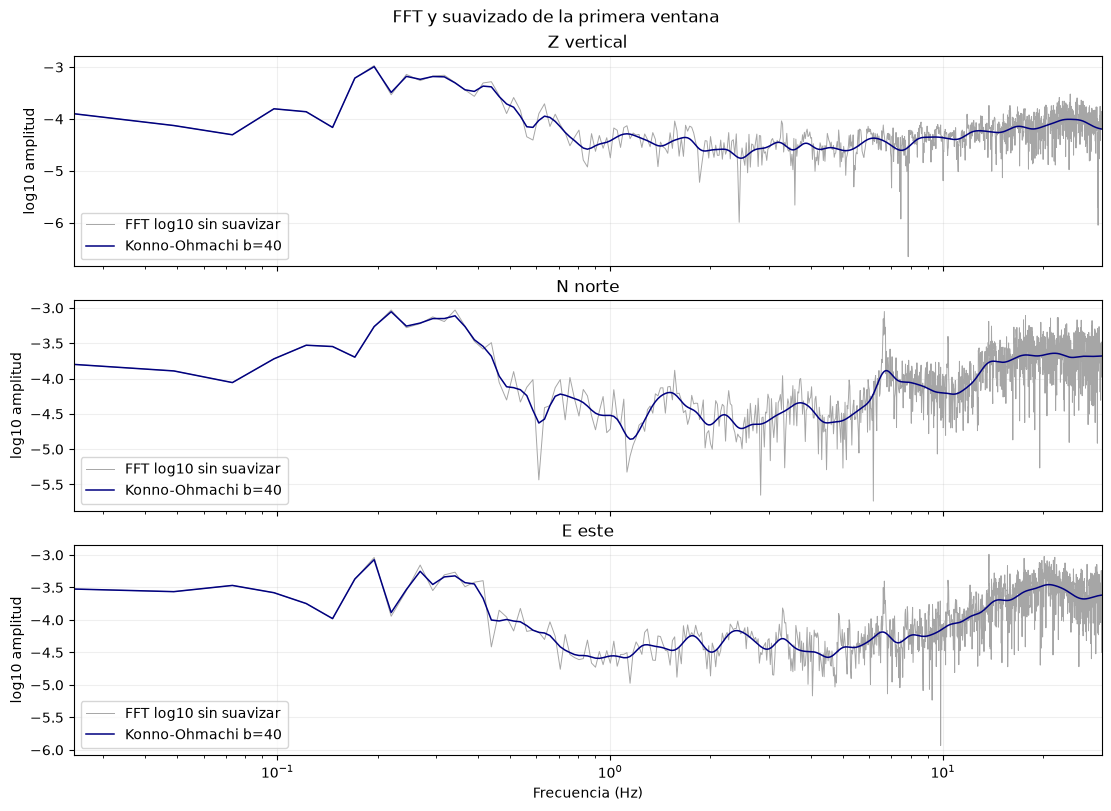

In [11]:
_example_window = 0
_component_names = ("Z vertical", "N norte", "E este")
fig, axes = plt.subplots(3, 1, figsize=(11, 8), sharex=True, constrained_layout=True)
for component, axis in enumerate(axes):
    axis.plot(frequency_hz, spectra_log_raw[_example_window, component], color="0.65", lw=0.7, label="FFT log10 sin suavizar")
    axis.plot(frequency_hz, spectra_log_ko[_example_window, component], color="navy", lw=1.1, label=f"Konno-Ohmachi b={PARAMS['ko_b']:g}")
    axis.set_ylabel("log10 amplitud")
    axis.set_title(_component_names[component])
    axis.grid(alpha=0.2)
    axis.legend()
axes[-1].set_xlabel("Frecuencia (Hz)")
axes[-1].set_xscale("log")
axes[-1].set_xlim(max(df_hz, frequency_hz[0]), frequency_hz[-1])
fig.suptitle("FFT y suavizado de la primera ventana")
plt.show()

## 6. Cociente H/V, promedio y picos

Para cada ventana $i$, la horizontal equivalente y el cociente son:

$$H_i(f)=\sqrt{\frac{N_i(f)^2+E_i(f)^2}{2}},\qquad HV_i(f)=\frac{H_i(f)}{Z_i(f)}.$$

El codigo MATLAB guarda primero $\log_{10}(HV_i)$. Su promedio aritmetico en log equivale a la media geometrica en amplitud:

$$\mu_{\log}(f)=\frac{1}{N_w}\sum_i\log_{10}HV_i(f),\qquad HV_{mean}(f)=10^{\mu_{\log}(f)}.$$

La desviacion muestral $\sigma_{\log}$ produce una envolvente multiplicativa $10^{\mu_{\log}\pm\sigma_{\log}}$. No es un intervalo de confianza formal: describe variabilidad entre las ventanas seleccionadas. Con una sola ventana no se puede estimar esa dispersion.

Pico de la curva media: f0=10.01 Hz; A0=4.744
Media geometrica de picos por ventana: 8.888 Hz
Desviacion muestral de log10(f0) entre ventanas: 0.145


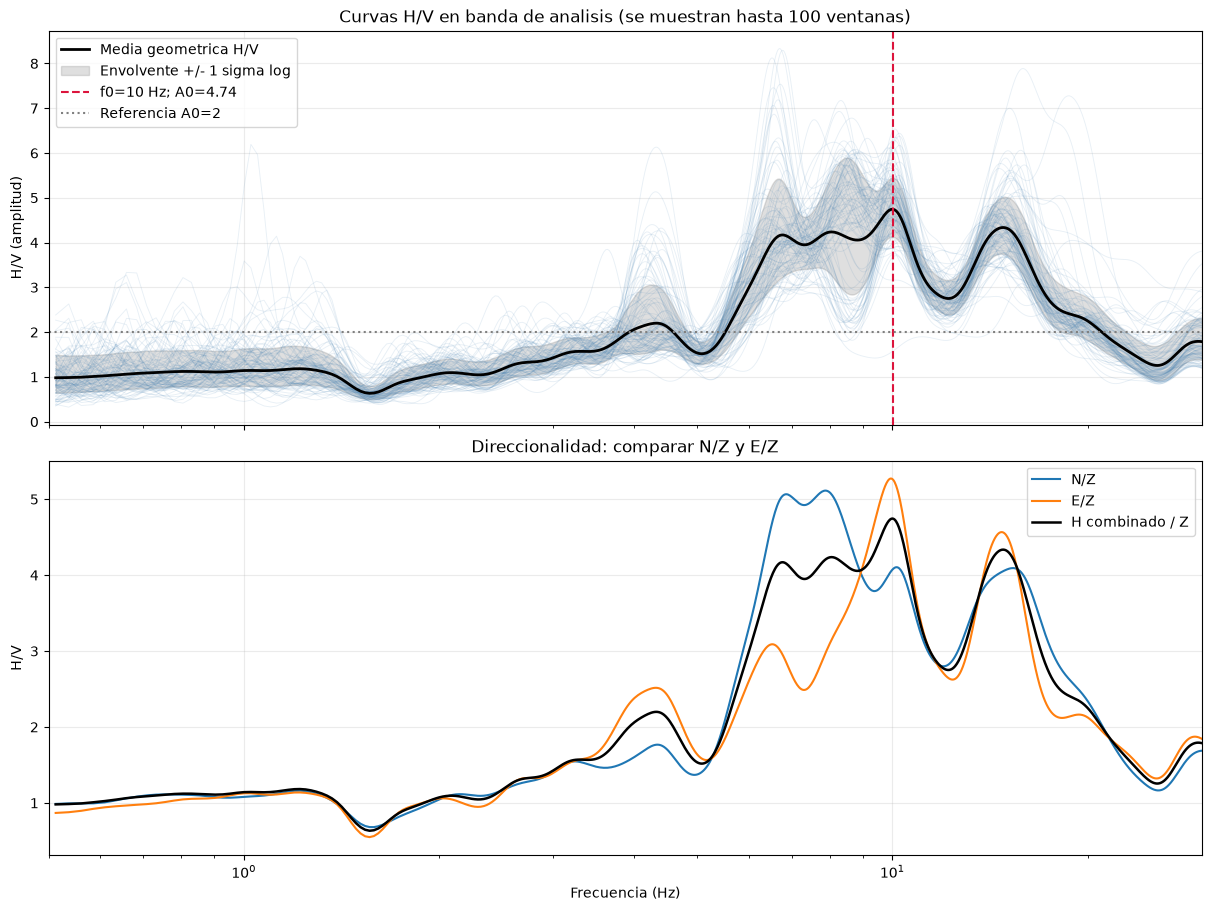

In [13]:
vertical_spectrum = spectra_linear[:, 0, :]
north_spectrum = spectra_linear[:, 1, :]
east_spectrum = spectra_linear[:, 2, :]
horizontal_spectrum = np.sqrt((north_spectrum ** 2 + east_spectrum ** 2) / 2.0)
tiny = np.finfo(float).tiny
hv_by_window = horizontal_spectrum / np.maximum(vertical_spectrum, tiny)
hv_north_by_window = north_spectrum / np.maximum(vertical_spectrum, tiny)
hv_east_by_window = east_spectrum / np.maximum(vertical_spectrum, tiny)
hv_log = np.log10(np.maximum(hv_by_window, tiny))
hv_mean_log = np.mean(hv_log, axis=0)
hv_mean = 10.0 ** hv_mean_log
if len(windows_idx) > 1:
    hv_sigma_log = np.std(hv_log, axis=0, ddof=1)
else:
    hv_sigma_log = np.full(frequency_hz.shape, np.nan)
hv_lower = 10.0 ** (hv_mean_log - hv_sigma_log)
hv_upper = 10.0 ** (hv_mean_log + hv_sigma_log)

search_band = frequency_hz >= PARAMS["sensor_low_hz"]
if not np.any(search_band):
    raise ValueError("No hay frecuencias en la banda de busqueda; revisa fs, n_fft y sensor_low_hz.")
search_indices = np.flatnonzero(search_band)
peak_index = search_indices[np.argmax(hv_mean[search_band])]
f0_hz = float(frequency_hz[peak_index])
A0 = float(hv_mean[peak_index])
window_peak_indices = search_indices[np.argmax(hv_by_window[:, search_band], axis=1)]
f0_by_window_hz = frequency_hz[window_peak_indices]
A0_by_window = hv_by_window[np.arange(len(windows_idx)), window_peak_indices]
if np.all(f0_by_window_hz > 0):
    f0_geometric_mean_hz = float(10.0 ** np.mean(np.log10(f0_by_window_hz)))
    f0_log_std = float(np.std(np.log10(f0_by_window_hz), ddof=1)) if len(f0_by_window_hz) > 1 else np.nan
else:
    f0_geometric_mean_hz, f0_log_std = np.nan, np.nan

HV_data = {
    "frequency_hz": frequency_hz,
    "HV_mean": hv_mean,
    "HV_lower_1sigma": hv_lower,
    "HV_upper_1sigma": hv_upper,
    "HV_N_over_Z_mean": 10.0 ** np.mean(np.log10(np.maximum(hv_north_by_window, tiny)), axis=0),
    "HV_E_over_Z_mean": 10.0 ** np.mean(np.log10(np.maximum(hv_east_by_window, tiny)), axis=0),
}

print(f"Pico de la curva media: f0={f0_hz:.4g} Hz; A0={A0:.4g}")
print(f"Media geometrica de picos por ventana: {f0_geometric_mean_hz:.4g} Hz")
print(f"Desviacion muestral de log10(f0) entre ventanas: {f0_log_std:.4g}")

plot_frequency = frequency_hz[search_band]
curve_ids = np.linspace(0, len(windows_idx) - 1, min(100, len(windows_idx)), dtype=int)
fig, axes = plt.subplots(2, 1, figsize=(12, 9), sharex=True, constrained_layout=True)
for window_id in curve_ids:
    axes[0].plot(plot_frequency, hv_by_window[window_id, search_band], color="steelblue", alpha=0.12, lw=0.65)
axes[0].plot(plot_frequency, hv_mean[search_band], color="black", lw=2.0, label="Media geometrica H/V")
if len(windows_idx) > 1:
    axes[0].fill_between(plot_frequency, hv_lower[search_band], hv_upper[search_band], color="gray", alpha=0.25, label="Envolvente +/- 1 sigma log")
axes[0].axvline(f0_hz, color="crimson", ls="--", label=f"f0={f0_hz:.3g} Hz; A0={A0:.3g}")
axes[0].axhline(2.0, color="0.5", ls=":", label="Referencia A0=2")
axes[0].set_ylabel("H/V (amplitud)")
axes[0].set_title("Curvas H/V en banda de analisis (se muestran hasta 100 ventanas)")
axes[0].legend()
axes[1].plot(plot_frequency, HV_data["HV_N_over_Z_mean"][search_band], label="N/Z")
axes[1].plot(plot_frequency, HV_data["HV_E_over_Z_mean"][search_band], label="E/Z")
axes[1].plot(plot_frequency, hv_mean[search_band], color="black", lw=1.8, label="H combinado / Z")
axes[1].set_ylabel("H/V")
axes[1].set_xlabel("Frecuencia (Hz)")
axes[1].set_title("Direccionalidad: comparar N/Z y E/Z")
axes[1].legend()
for axis in axes:
    axis.set_xscale("log")
    axis.set_xlim(PARAMS["sensor_low_hz"], frequency_hz[-1])
    axis.grid(alpha=0.25)
plt.show()

## 7. Estadistica descriptiva y criterios de calidad

Por ventana se guarda el maximo de H/V y su frecuencia. La media geometrica de $f_0$ y su desviacion en $\log_{10}(f_0)$ resumen consistencia. Un bootstrap entre ventanas puede dar un intervalo descriptivo para esa media; solo tiene interpretacion aproximada si las ventanas son suficientemente independientes (sin solape no garantiza independencia).

`crit_SESAM.m` produce nueve indicadores. La celda siguiente muestra la logica y las bandas que usa este codigo heredado:

1. Resolucion de la ventana: $f_0>10/L_w$, con $L_w$ en segundos.
2. Duracion total: $N_wL_wf_0>200$.
3. Estabilidad de amplitud: para cada frecuencia en $(0.5f_0,2f_0)$, la desviacion de $\log_{10}(H/V)$ es menor que 2.
4. Forma del pico por debajo: debe existir al menos un punto en $(0.25f_0,f_0)$ con $HV(f)<A_0/2$.
5. Forma del pico por encima: debe existir al menos un punto en $(f_0,4f_0)$ con $HV(f)<A_0/2$.
6. Amplitud: $A_0>2$.
7. Frecuencia de picos derivados de las envolventes: ambos deben quedar dentro de +/-5 % de $f_0$.
8. Dispersión entre ventanas: el script compara `std(log10(f0_i))` con $\epsilon$, donde $\epsilon$ toma $0.2f_0$, $0.15f_0$, $0.1f_0$ o $0.05f_0$ segun la banda de $f_0$.
9. Estabilidad local: la dispersion logaritmica alrededor de $f_0$ se compara con $\theta=2.5,2,1.78$ o $1.58$, tambien segun la banda.

**Cautela:** el punto 8 compara una desviacion en logaritmos con un umbral en Hz; las unidades no coinciden, por lo que se imprime como indicador literal cuestionable, no como veredicto valido. El original tambien tiene detalles de indices y busqueda de picos que pueden diferir de la guia SESAME elegida. Ningun criterio sustituye el juicio geologico ni constituye por si solo certificacion del sitio.

Criterio / diagnostico (None = no evaluable):
  1: resolucion/ventana: True
  2: duracion total: True
  3: estabilidad 0.5-2 f0: True
  4: caida lado bajo: True
  5: caida lado alto: True
  6: amplitud A0 > 2: True
  7: picos envolvente dentro de +/-5%: False
  8: dispersion literal (cuestionable): True
  9: variabilidad local: True
Picos de las envolventes cerca de f0: bajo=9.985 Hz, alto=9.009 Hz
IC bootstrap descriptivo 95% de media geometrica f0: 8.695-9.092 Hz


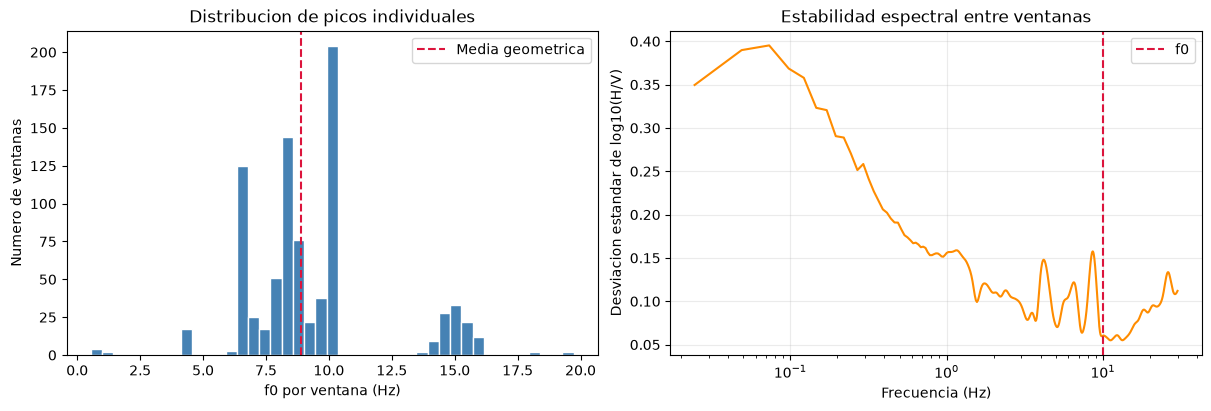

In [21]:
def sesame_like_diagnostics(frequency, hv_mean_curve, hv_sigma_log_curve,
                           f0, a0, window_length_s, n_windows,
                           f0_log_std, f0_windows):
    """Indicadores didacticos basados en el codigo fuente, no certificacion SESAME."""
    if len(f0_windows) != n_windows:
        raise ValueError("Debe haber exactamente un pico por cada ventana aceptada.")
    df = float(frequency[1] - frequency[0])
    local = (frequency > f0 - df) & (frequency < f0 + df)
    around = (frequency > 0.5 * f0) & (frequency < 2.0 * f0)
    left = (frequency > 0.25 * f0) & (frequency < f0)
    right = (frequency > f0) & (frequency < 4.0 * f0)
    band_peak = (frequency >= 0.9 * f0) & (frequency <= 1.1 * f0)
    result = {
        "1: resolucion/ventana": bool(f0 > 10.0 / window_length_s),
        "2: duracion total": bool(n_windows * window_length_s * f0 > 200.0),
        "3: estabilidad 0.5-2 f0": bool(np.any(around) and np.all(hv_sigma_log_curve[around] < 2.0)),
        "4: caida lado bajo": bool(np.any(left) and np.any(hv_mean_curve[left] < a0 / 2.0)),
        "5: caida lado alto": bool(np.any(right) and np.any(hv_mean_curve[right] < a0 / 2.0)),
        "6: amplitud A0 > 2": bool(a0 > 2.0),
    }
    if np.any(band_peak) and np.all(np.isfinite(hv_lower[band_peak])) and np.all(np.isfinite(hv_upper[band_peak])):
        f0_lower = float(frequency[band_peak][np.argmax(hv_lower[band_peak])])
        f0_upper = float(frequency[band_peak][np.argmax(hv_upper[band_peak])])
        result["7: picos envolvente dentro de +/-5%"] = bool(
            0.95 * f0 <= f0_lower <= 1.05 * f0 and 0.95 * f0 <= f0_upper <= 1.05 * f0
        )
    else:
        f0_lower = f0_upper = np.nan
        result["7: picos envolvente dentro de +/-5%"] = None

    if 0.2 < f0 <= 0.5:
        eps_fraction, theta = 0.20, 2.5
    elif 0.5 < f0 <= 1.0:
        eps_fraction, theta = 0.15, 2.0
    elif 1.0 < f0 <= 2.0:
        eps_fraction, theta = 0.10, 1.78
    elif f0 > 2.0:
        eps_fraction, theta = 0.05, 1.58
    else:
        eps_fraction = theta = np.nan
    result["8: dispersion literal (cuestionable)"] = (
        bool(f0_log_std < eps_fraction * f0) if np.isfinite(f0_log_std) and np.isfinite(eps_fraction) else None
    )
    result["9: variabilidad local"] = (
        bool(np.any(local) and np.all(hv_sigma_log_curve[local] < theta)) if np.isfinite(theta) else None
    )
    return result, f0_lower, f0_upper


quality_checks, f0_lower_envelope, f0_upper_envelope = sesame_like_diagnostics(
    frequency_hz, hv_mean, hv_sigma_log, f0_hz, A0,
    PARAMS["window_min_s"], len(windows_idx), f0_log_std, f0_by_window_hz,
)
print("Criterio / diagnostico (None = no evaluable):")
for name, passed in quality_checks.items():
    print(f"  {name}: {passed}")
print(f"Picos de las envolventes cerca de f0: bajo={f0_lower_envelope:.4g} Hz, alto={f0_upper_envelope:.4g} Hz")
if np.isfinite(f0_log_std):
    bootstrap = np.array([
        10.0 ** np.mean(np.log10(rng.choice(f0_by_window_hz, size=len(f0_by_window_hz), replace=True)))
        for _ in range(2000)
    ])
    f0_bootstrap_ci = np.quantile(bootstrap, [0.025, 0.975])
    print(f"IC bootstrap descriptivo 95% de media geometrica f0: {f0_bootstrap_ci[0]:.4g}-{f0_bootstrap_ci[1]:.4g} Hz")
else:
    f0_bootstrap_ci = np.array([np.nan, np.nan])
    print("Bootstrap no estimable con menos de dos ventanas.")

fig, axes = plt.subplots(1, 2, figsize=(12, 4), constrained_layout=True)
axes[0].hist(f0_by_window_hz, bins="auto", color="steelblue", edgecolor="white")
axes[0].axvline(f0_geometric_mean_hz, color="crimson", ls="--", label="Media geometrica")
axes[0].set_xlabel("f0 por ventana (Hz)")
axes[0].set_ylabel("Numero de ventanas")
axes[0].set_title("Distribucion de picos individuales")
axes[0].legend()
axes[1].plot(frequency_hz, hv_sigma_log, color="darkorange")
axes[1].axvline(f0_hz, color="crimson", ls="--", label="f0")
axes[1].set_xscale("log")
axes[1].set_xlabel("Frecuencia (Hz)")
axes[1].set_ylabel("Desviacion estandar de log10(H/V)")
axes[1].set_title("Estabilidad espectral entre ventanas")
axes[1].legend()
axes[1].grid(alpha=0.25)
plt.show()

## 8. Verificacion numerica y significado geologico

Un ejemplo sintetico permite verificar unidades y formulas sin atribuir datos artificiales al sitio. Construiremos dos tramos de 32 s con tonos controlados; una sinusoide de 1 Hz tiene amplitudes $Z=1$, $N=4$, $E=2$. Si esas amplitudes se comparan en la misma frecuencia, la ecuacion predice $H/V=\sqrt{(4^2+2^2)/2}=\sqrt{10}$. Las pruebas siguientes comprueban conversion s->muestras, longitud de ventana, frecuencia espectral y esta combinacion horizontal.

### Interpretacion geologica: modelo de cuarto de longitud de onda

Para una capa aproximadamente horizontal de espesor $H$ y velocidad de onda S $V_s$ sobre un sustrato con contraste de impedancia, una aproximacion es:

$$T_0\approx\frac{4H}{V_s},\qquad f_0=\frac{1}{T_0}\approx\frac{V_s}{4H},\qquad H\approx\frac{V_s}{4f_0}.$$

Ejemplo **hipotetico**: si $V_s=300\,m/s$ y $f_0=1.5\,Hz$, resulta $H\approx50\,m$. El pico por si solo no separa cambios de espesor de cambios de velocidad; varias capas, topografia y geometria lateral requieren modelos/datos adicionales. La amplitud H/V $A_0$ tampoco es directamente un factor de amplificacion del movimiento sismico.

Pruebas sinteticas superadas.
dt=0.0078125 s; Fs=128 Hz; ventanas=[[0, 4096], [4096, 8192]]; df=0.03125 Hz
H/V esperado a 1 Hz = sqrt(10) = 3.162278; obtenido = 3.162278


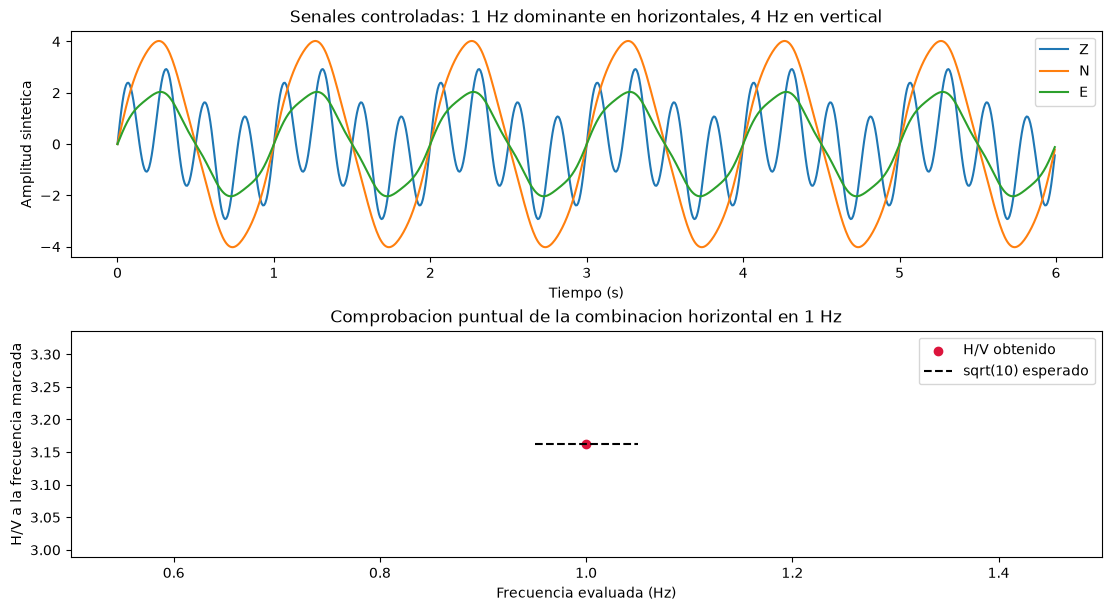

Ejemplo geologico hipotetico: Vs=300 m/s, f0=1.5 Hz -> H~50 m


In [17]:
test_fs = 128.0
test_duration_s = 64.0
test_time = np.arange(int(test_fs * test_duration_s)) / test_fs
test_data = np.column_stack((
    np.sin(2 * np.pi * 1.0 * test_time) + 2.0 * np.sin(2 * np.pi * 4.0 * test_time),
    4.0 * np.sin(2 * np.pi * 1.0 * test_time) + 0.1 * np.sin(2 * np.pi * 4.0 * test_time),
    2.0 * np.sin(2 * np.pi * 1.0 * test_time) + 0.1 * np.sin(2 * np.pi * 4.0 * test_time),
))
test_params = dict(PARAMS, window_min_s=32.0, window_max_s=32.0,
                   variable_windows=False, overlap_percent=0.0, fmax_hz=20.0)
test_windows = select_windows(np.ones(len(test_data), dtype=bool), test_fs, test_params)
test_frequency, test_log_spectrum, test_nfft = spectra_by_window(
    test_data, test_windows, test_fs, test_params, taper_mode="none"
)
test_linear_spectrum = 10.0 ** test_log_spectrum
idx_1hz = int(np.argmin(np.abs(test_frequency - 1.0)))
test_h_1hz = np.sqrt((test_linear_spectrum[:, 1, idx_1hz] ** 2 + test_linear_spectrum[:, 2, idx_1hz] ** 2) / 2.0)
test_hv_1hz = test_h_1hz / test_linear_spectrum[:, 0, idx_1hz]
expected_hv_1hz = np.sqrt((4.0 ** 2 + 2.0 ** 2) / 2.0)

assert np.isclose(1.0 / (1.0 / test_fs), test_fs)
assert test_windows.shape == (2, 2)
assert np.all(test_windows[:, 1] - test_windows[:, 0] == int(32.0 * test_fs))
assert test_nfft == 4096 and np.isclose(test_frequency[idx_1hz], 1.0)
assert np.allclose(test_hv_1hz, expected_hv_1hz, rtol=1e-10)
print("Pruebas sinteticas superadas.")
print(f"dt={1/test_fs:.6g} s; Fs={test_fs:g} Hz; ventanas={test_windows.tolist()}; df={test_fs/test_nfft:g} Hz")
print(f"H/V esperado a 1 Hz = sqrt(10) = {expected_hv_1hz:.6f}; obtenido = {np.mean(test_hv_1hz):.6f}")

fig, axes = plt.subplots(2, 1, figsize=(11, 6), constrained_layout=True)
for column, label in enumerate(("Z", "N", "E")):
    axes[0].plot(test_time[:6 * int(test_fs)], test_data[:6 * int(test_fs), column], label=label)
axes[0].set_xlabel("Tiempo (s)")
axes[0].set_ylabel("Amplitud sintetica")
axes[0].set_title("Senales controladas: 1 Hz dominante en horizontales, 4 Hz en vertical")
axes[0].legend()
axes[1].scatter([test_frequency[idx_1hz]], [np.mean(test_hv_1hz)], color="crimson", label="H/V obtenido")
axes[1].hlines(expected_hv_1hz, 0.95, 1.05, color="black", ls="--", label="sqrt(10) esperado")
axes[1].set_xlim(0.5, 1.5)
axes[1].set_xlabel("Frecuencia evaluada (Hz)")
axes[1].set_ylabel("H/V a la frecuencia marcada")
axes[1].set_title("Comprobacion puntual de la combinacion horizontal en 1 Hz")
axes[1].legend()
plt.show()

vs_example_m_s, f0_example_hz = 300.0, 1.5
thickness_example_m = vs_example_m_s / (4.0 * f0_example_hz)
print(f"Ejemplo geologico hipotetico: Vs={vs_example_m_s:g} m/s, f0={f0_example_hz:g} Hz -> H~{thickness_example_m:g} m")

## 9. Esquema del flujo y dependencias

```mermaid
flowchart LR
    SAC["Tres SAC sincronizados: E, N, Z"] --> QC["Validar canales, dt, Fs, inicio y longitud"]
    QC --> PRE["Quitar media + taper elegido"]
    PRE --> TR["Magnitud vectorial y STA/LTA"]
    TR --> WIN["Mascara valida -> ventanas [inicio, fin)"]
    WIN --> FFT["FFT positiva + zero-padding"]
    FFT --> KO["Suavizado KO en log10 amplitud"]
    KO --> HV["H=sqrt((N^2+E^2)/2); H/V"]
    HV --> AVG["Media geometrica y dispersion"]
    AVG --> PEAK["f0, A0, picos por ventana"]
    PEAK --> QA["Diagnosticos tipo SESAME + sensibilidad"]
    QA --> GEO["Interpretacion con geologia, Vs y limites"]
    QA --> OUT["CSV, JSON y figura reproducible"]
```

Dependencias computacionales: NumPy para operaciones y FFT, Matplotlib para graficas y ObsPy para leer SAC. Los calculos de HVSR y las simulaciones de prueba no requieren pandas ni SciPy.

## 10. Sensibilidad y ablacion del procesamiento

Una estimacion que cambia mucho al modificar un parametro puede ser poco robusta. La siguiente prueba cambia el ancho KO ($b=20,40,80$) y el taper (`cosine`, `matlab-edge`, `none`), usando hasta ocho ventanas distribuidas a lo largo de todo el registro para aislar el efecto espectral sin privilegiar solo el inicio. Tambien cambia `ratio_max` para medir cuantas ventanas sobreviven a STA/LTA. Es una sensibilidad descriptiva, no una optimizacion para forzar un pico deseado.

Si hay muchas ventanas, se limita este diagnostico a una muestra distribuida de hasta ocho para mantenerlo agil; el resultado principal continua usando todas.

Sensibilidad espectral en indices de ventana distribuidos: [0, 120, 240, 360, 480, 600, 720, 841]
taper=     cosine | b=  20 | f0=14.917 Hz | A0=4.0125
taper=     cosine | b=  40 | f0=15.088 Hz | A0=4.5946
taper=     cosine | b=  80 | f0=6.8115 Hz | A0=5.2068
taper=matlab-edge | b=  20 | f0=9.375 Hz | A0=4
taper=matlab-edge | b=  40 | f0=15.063 Hz | A0=4.5488
taper=matlab-edge | b=  80 | f0=10.303 Hz | A0=5.0919
taper=       none | b=  20 | f0=14.941 Hz | A0=4.0258
taper=       none | b=  40 | f0=15.112 Hz | A0=4.5826
taper=       none | b=  80 | f0=10.327 Hz | A0=5.1127

Sensibilidad a ratio_max: (umbral, puntos aceptados, ventanas)
(1.5, 2739124, 730)
(2.0, 2783882, 842)
(2.5, 2792731, 850)
(3.0, 2796831, 857)


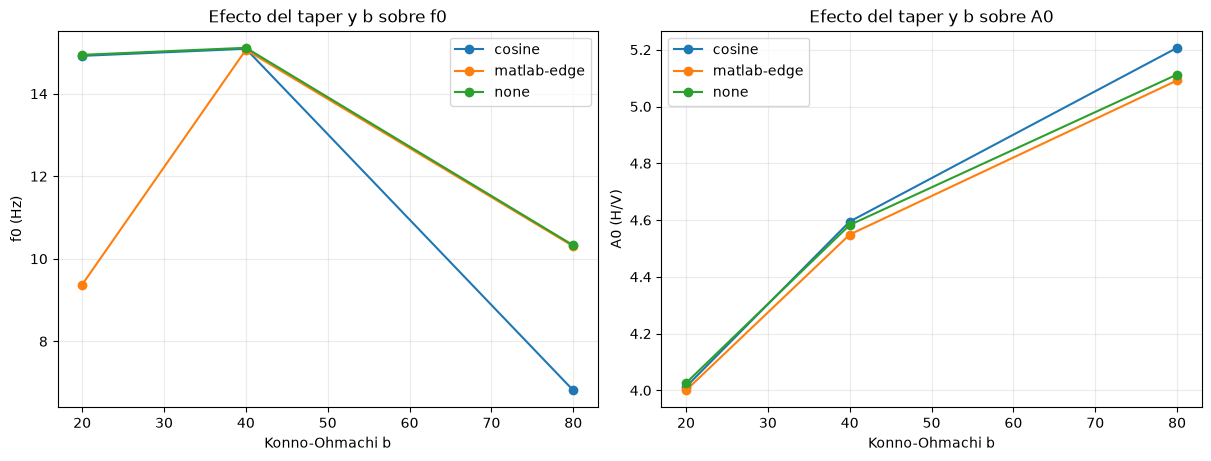

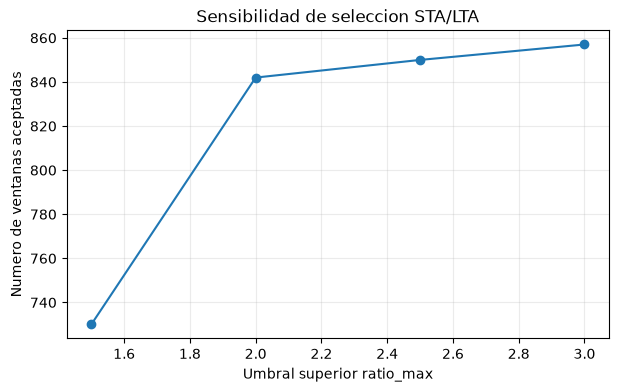

In [18]:
sensitivity_ids = np.unique(np.linspace(0, len(windows_idx) - 1, min(8, len(windows_idx)), dtype=int))
sensitivity_windows = windows_idx[sensitivity_ids]
sensitivity_rows = []
for taper_mode in ("cosine", "matlab-edge", "none"):
    for ko_b in (20.0, 40.0, 80.0):
        local_params = dict(PARAMS, ko_b=ko_b)
        f_sens, log_raw_sens, _ = spectra_by_window(data, sensitivity_windows, fs, local_params, taper_mode)
        log_ko_sens = konno_ohmachi_log(f_sens, log_raw_sens, ko_b)
        linear_sens = 10.0 ** log_ko_sens
        h_sens = np.sqrt((linear_sens[:, 1, :] ** 2 + linear_sens[:, 2, :] ** 2) / 2.0)
        hv_sens = h_sens / np.maximum(linear_sens[:, 0, :], tiny)
        mean_sens = 10.0 ** np.mean(np.log10(np.maximum(hv_sens, tiny)), axis=0)
        band_sens = f_sens >= PARAMS["sensor_low_hz"]
        peak_sens_idx = np.flatnonzero(band_sens)[np.argmax(mean_sens[band_sens])]
        sensitivity_rows.append({
            "taper": taper_mode, "b": ko_b,
            "f0_hz": float(f_sens[peak_sens_idx]),
            "A0": float(mean_sens[peak_sens_idx]),
        })

threshold_rows = []
for upper_threshold in (1.5, 2.0, 2.5, 3.0):
    test_params = dict(PARAMS, ratio_max=upper_threshold)
    test_trigger = calculate_trigger(data, fs, test_params, TAPER_MODE, TRIGGER_INIT_MODE)
    test_windows = select_windows(test_trigger["valid"], fs, test_params)
    threshold_rows.append((upper_threshold, int(test_trigger["valid"].sum()), len(test_windows)))

print(f"Sensibilidad espectral en indices de ventana distribuidos: {sensitivity_ids.tolist()}")
for row in sensitivity_rows:
    print(f"taper={row['taper']:>11s} | b={row['b']:>4.0f} | f0={row['f0_hz']:.5g} Hz | A0={row['A0']:.5g}")
print("\nSensibilidad a ratio_max: (umbral, puntos aceptados, ventanas)")
for row in threshold_rows:
    print(row)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5), constrained_layout=True)
for taper_mode in ("cosine", "matlab-edge", "none"):
    group = [row for row in sensitivity_rows if row["taper"] == taper_mode]
    axes[0].plot([row["b"] for row in group], [row["f0_hz"] for row in group], marker="o", label=taper_mode)
    axes[1].plot([row["b"] for row in group], [row["A0"] for row in group], marker="o", label=taper_mode)
axes[0].set_xlabel("Konno-Ohmachi b")
axes[0].set_ylabel("f0 (Hz)")
axes[0].set_title("Efecto del taper y b sobre f0")
axes[1].set_xlabel("Konno-Ohmachi b")
axes[1].set_ylabel("A0 (H/V)")
axes[1].set_title("Efecto del taper y b sobre A0")
for axis in axes:
    axis.grid(alpha=0.25)
    axis.legend()
plt.show()

fig, axis = plt.subplots(figsize=(7, 4))
axis.plot([row[0] for row in threshold_rows], [row[2] for row in threshold_rows], marker="o")
axis.set_xlabel("Umbral superior ratio_max")
axis.set_ylabel("Numero de ventanas aceptadas")
axis.set_title("Sensibilidad de seleccion STA/LTA")
axis.grid(alpha=0.25)
plt.show()

## 11. Exportacion y reproducibilidad

La ultima celda crea `main/02_analysis_hv/outputs_hvsr/` con la curva media y su envolvente en CSV, picos por ventana, sensibilidades, parametros/configuracion JSON, resumen de diagnosticos y una figura PNG. Guarda fuente (`SAC` o `synthetic`), semilla, `Fs`, `dt`, taper, modo STA/LTA, NFFT, `df` y cantidad de ventanas. Los resultados se generan solo al ejecutar esta celda; revisar que `DATA_SOURCE` indique correctamente el origen antes de compartirlos.

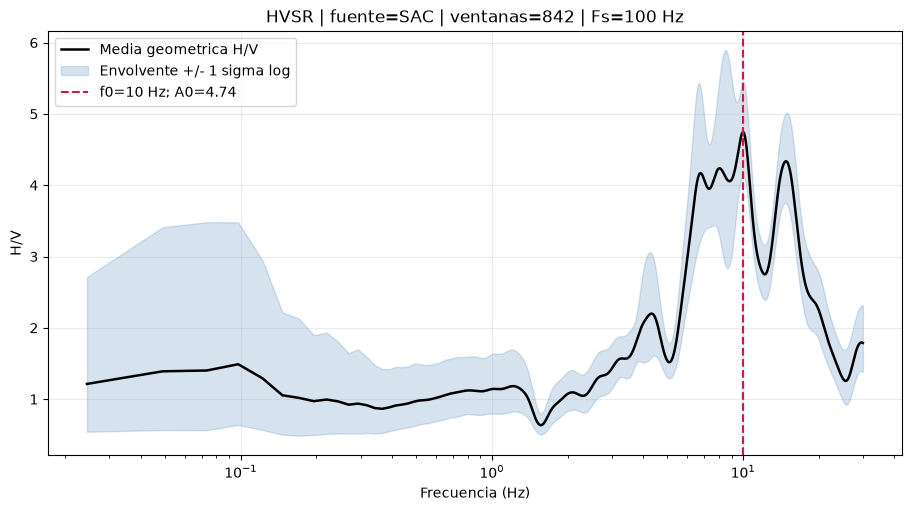

Artefactos escritos en: /home/orincon/ciudad-perdida-hvsr/main/02_analysis_hv/outputs_hvsr
 - experiment.json
 - hv_curve.csv
 - hv_curve.png
 - sensitivity.csv
 - summary.md
 - window_peaks.csv


In [22]:
import csv
import json
from datetime import datetime, timezone
from importlib.metadata import PackageNotFoundError, version

OUTPUT_DIR = PROJECT_ROOT / "main" / "02_analysis_hv" / "outputs_hvsr"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

curve_matrix = np.column_stack((
    frequency_hz, hv_mean, hv_lower, hv_upper,
    HV_data["HV_N_over_Z_mean"], HV_data["HV_E_over_Z_mean"],
))
np.savetxt(
    OUTPUT_DIR / "hv_curve.csv", curve_matrix, delimiter=",",
    header="frequency_hz,HV_geometric_mean,HV_lower_1sigma,HV_upper_1sigma,HV_N_over_Z,HV_E_over_Z",
    comments="",
)
window_matrix = np.column_stack((
    windows_idx[:, 0], windows_idx[:, 1], windows_idx[:, 0] / fs,
    windows_idx[:, 1] / fs, f0_by_window_hz, A0_by_window,
))
np.savetxt(
    OUTPUT_DIR / "window_peaks.csv", window_matrix, delimiter=",",
    header="start_sample_inclusive,end_sample_exclusive,start_time_s,end_time_exclusive_s,f0_hz,A0",
    comments="", fmt=["%d", "%d", "%.9g", "%.9g", "%.9g", "%.9g"],
)
with (OUTPUT_DIR / "sensitivity.csv").open("w", newline="", encoding="utf-8") as handle:
    writer = csv.DictWriter(handle, fieldnames=("taper", "b", "f0_hz", "A0"))
    writer.writeheader()
    writer.writerows(sensitivity_rows)

try:
    obspy_version = version("obspy")
except PackageNotFoundError:
    obspy_version = None
experiment = {
    "created_utc": datetime.now(timezone.utc).isoformat(),
    "source": DATA_SOURCE,
    "source_files": {key: str(path) for key, path in SAC_FILES.items()} if DATA_SOURCE == "SAC" else "synthetic demonstration",
    "random_seed": SEED,
    "parameters": PARAMS,
    "taper_mode": TAPER_MODE,
    "trigger_initialization": TRIGGER_INIT_MODE,
    "data_shape_samples_components": list(data.shape),
    "dt_seconds": float(dt), "sampling_rate_hz": float(fs), "nyquist_hz": float(nyquist),
    "number_of_windows": int(len(windows_idx)), "n_fft": int(n_fft), "df_hz": float(df_hz),
    "f0_hz": f0_hz, "A0": A0,
    "f0_geometric_mean_windows_hz": f0_geometric_mean_hz,
    "f0_log_std_windows": f0_log_std,
    "f0_bootstrap_95pct_hz": [float(x) if np.isfinite(x) else None for x in f0_bootstrap_ci],
    "quality_diagnostics": quality_checks,
    "versions": {"python": platform.python_version(), "numpy": np.__version__,
                  "matplotlib": plt.matplotlib.__version__, "obspy": obspy_version},
}
with (OUTPUT_DIR / "experiment.json").open("w", encoding="utf-8") as handle:
    json.dump(experiment, handle, indent=2, ensure_ascii=False, allow_nan=False)

fig, axis = plt.subplots(figsize=(9, 5), constrained_layout=True)
axis.plot(frequency_hz, hv_mean, color="black", lw=1.8, label="Media geometrica H/V")
if len(windows_idx) > 1:
    axis.fill_between(frequency_hz, hv_lower, hv_upper, color="steelblue", alpha=0.22, label="Envolvente +/- 1 sigma log")
axis.axvline(f0_hz, color="crimson", ls="--", label=f"f0={f0_hz:.3g} Hz; A0={A0:.3g}")
axis.set_xscale("log")
axis.set_xlabel("Frecuencia (Hz)")
axis.set_ylabel("H/V")
axis.set_title(f"HVSR | fuente={DATA_SOURCE} | ventanas={len(windows_idx)} | Fs={fs:g} Hz")
axis.grid(alpha=0.25)
axis.legend()
fig.savefig(OUTPUT_DIR / "hv_curve.png", dpi=180)
plt.show()

report_lines = [
    "# Resumen HVSR reproducible", "",
    f"- Fuente: {DATA_SOURCE}", f"- Ventanas: {len(windows_idx)}",
    f"- Fs: {fs:g} Hz; dt: {dt:g} s; df: {df_hz:g} Hz",
    f"- Taper: {TAPER_MODE}; inicializacion STA/LTA: {TRIGGER_INIT_MODE}",
    f"- Pico de curva media: f0={f0_hz:.6g} Hz, A0={A0:.6g}",
    f"- Media geometrica de picos por ventana: {f0_geometric_mean_hz:.6g} Hz",
    "", "Los criterios y las amplitudes HVSR son diagnosticos, no una estimacion directa de amplificacion.",
]
(OUTPUT_DIR / "summary.md").write_text("\n".join(report_lines) + "\n", encoding="utf-8")
print("Artefactos escritos en:", OUTPUT_DIR)
for path in sorted(OUTPUT_DIR.iterdir()):
    print(" -", path.name)